## 1. Data preprocessing

In [1]:
import pandas as pd

data_path = "../data/HELOC/"
# Note: include or not the index column: index_col=0
df = pd.read_csv(data_path + "heloc_dataset_v1.csv")
df.reset_index(drop=True, inplace=True)


In [2]:
# # NOTEARS and ReX require numeric, complete matrices, so missing data must be resolved.
# df = df.fillna(df.median())

print(df.shape)
df = df.dropna()
df.head()

print(df.shape)

(10459, 24)
(10459, 24)


In [3]:
# Only supports numeric input. Categorical features must be encoded numerically.
df.dtypes

RiskPerformance                       object
ExternalRiskEstimate                   int64
MSinceOldestTradeOpen                  int64
MSinceMostRecentTradeOpen              int64
AverageMInFile                         int64
NumSatisfactoryTrades                  int64
NumTrades60Ever2DerogPubRec            int64
NumTrades90Ever2DerogPubRec            int64
PercentTradesNeverDelq                 int64
MSinceMostRecentDelq                   int64
MaxDelq2PublicRecLast12M               int64
MaxDelqEver                            int64
NumTotalTrades                         int64
NumTradesOpeninLast12M                 int64
PercentInstallTrades                   int64
MSinceMostRecentInqexcl7days           int64
NumInqLast6M                           int64
NumInqLast6Mexcl7days                  int64
NetFractionRevolvingBurden             int64
NetFractionInstallBurden               int64
NumRevolvingTradesWBalance             int64
NumInstallTradesWBalance               int64
NumBank2Na

In [4]:
pd.value_counts(df['RiskPerformance'])

/var/folders/4x/nynq10qj2kz8_zbvh7mnk0y00000gn/T/ipykernel_48702/2865858456.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['RiskPerformance'])


RiskPerformance
Bad     5459
Good    5000
Name: count, dtype: int64

In [5]:
df.describe()

,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
count,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,...,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000
mean,67.425758,184.205373,8.543455,73.843293,19.428052,0.042738,-0.142843,86.661536,6.762406,4.928291,...,32.166460,-0.325366,0.868152,0.812602,31.629888,39.158906,3.185008,0.976097,0.018071,62.079166
std,21.121621,109.683816,13.301745,38.782803,13.004327,2.513910,2.367397,25.999584,20.501250,3.756275,...,20.128634,6.067556,3.179304,3.143698,30.060140,42.101601,4.413173,4.060995,3.358135,27.711565
min,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,...,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,63.000000,118.000000,3.000000,52.000000,12.000000,0.000000,0.000000,87.000000,-7.000000,4.000000,...,20.000000,-7.000000,0.000000,0.000000,5.000000,-8.000000,2.000000,1.000000,0.000000,47.000000
50%,71.000000,178.000000,5.000000,74.000000,19.000000,0.000000,0.000000,96.000000,-7.000000,6.000000,...,31.000000,0.000000,1.000000,1.000000,25.000000,47.000000,3.000000,2.000000,0.000000,67.000000
75%,79.000000,249.500000,11.000000,95.000000,27.000000,1.000000,0.000000,100.000000,14.000000,7.000000,...,44.000000,1.000000,2.000000,2.000000,54.000000,79.000000,5.000000,3.000000,1.000000,82.000000
max,94.000000,803.000000,383.000000,383.000000,79.000000,19.000000,19.000000,100.000000,83.000000,9.000000,...,100.000000,24.000000,66.000000,66.000000,232.000000,471.000000,32.000000,23.000000,18.000000,100.000000


In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


class HELOCDataPreprocessor:
    """
    Preprocessing pipeline for the dataset
    Causal discovery–ready (ReX / NOTEARS / PC / GES)
    """

    def __init__(
        self,
        path,
        test_size=0.2,
        random_state=42,
        subsample_ratio=1.0,  # 1.0 = balanced, None = full dataset
    ):
        self.path = path
        self.test_size = test_size
        self.random_state = random_state
        self.subsample_ratio = subsample_ratio

        self.target_var = "RiskPerformance"

        # --------------------
        # Variable definitions
        # --------------------

        # Context (protected / non-actionable)
        self.context_vars = ["MSinceOldestTradeOpen", "AverageMInFile"]

        # NOTE: add context variables ["MSinceOldestTradeOpen", "AverageMInFile"] as numeric_vars
        # Actionable numeric variables
        self.numeric_vars = [
            "NumSatisfactoryTrades",
            "NumTrades60Ever2DerogPubRec",
            "NumTrades90Ever2DerogPubRec",
            "PercentTradesNeverDelq",
            "MSinceMostRecentDelq",
            "MaxDelq2PublicRecLast12M",
            "MaxDelqEver",
            "NumTotalTrades",
            "NumTradesOpeninLast12M",
            "PercentInstallTrades",
            "MSinceMostRecentInqexcl7days",
            "NumInqLast6M",  # or NumInqLast6Mexcl7days
            "NetFractionRevolvingBurden",
            "NetFractionInstallBurden",
            "NumRevolvingTradesWBalance",
            "NumInstallTradesWBalance",
            "NumBank2NatlTradesWHighUtilization",
            "PercentTradesWBalance",
            "MSinceOldestTradeOpen", 
            "AverageMInFile"
        ]

        # NOTE: add context variables [] as categorical_vars
        # Actionable categorical variables
        self.categorical_vars = []
        
        self.immutable_vars = ["MSinceMostRecentTradeOpen"]

        self.causal_graph_vars = self.numeric_vars + self.categorical_vars

        self._build_pipeline()

    # ------------------------------------------------------------------
    # Pipeline
    # ------------------------------------------------------------------
    def _build_pipeline(self):
        self.pipeline = ColumnTransformer(
            transformers=[
                (
                    "numeric",
                    Pipeline(
                        steps=[
                            ("impute", SimpleImputer(strategy="median")),
                            ("scale", StandardScaler()),
                        ]
                    ),
                    self.numeric_vars,
                ),
                (
                    "categorical",
                    Pipeline(
                        steps=[
                            ("impute", SimpleImputer(strategy="most_frequent")),
                            (
                                "encode",
                                OrdinalEncoder(
                                    handle_unknown="use_encoded_value", unknown_value=-1
                                ),
                            ),
                        ]
                    ),
                    self.categorical_vars,
                ),
            ],
            remainder="drop",
        )

    # ------------------------------------------------------------------
    # Main API
    # ------------------------------------------------------------------
    def load_and_process(self):
        df = pd.read_csv(self.path + "heloc_dataset_v1.csv")

        # --------------------
        # Drop missing
        # --------------------
        df = df.dropna().reset_index(drop=True)

        # --------------------
        # Target
        # --------------------
        # Binary encode target
        self.clss_lbls = ["Bad", "Good"]
        y = (df[self.target_var] == "Good").astype(int).values
        # y = df[self.target].astype(int).values

        # # --------------------
        # # Context encoding
        # # --------------------
        # context = df[self.context_vars].copy().astype(int)

        # --------------------
        # Features for causal discovery
        # --------------------
        X = df[self.causal_graph_vars].copy()

        # --------------------
        # Optional subsampling to balance classes
        # --------------------
        if self.subsample_ratio is not None:
            rng = np.random.default_rng(self.random_state)

            idx_pos = np.where(y == 1)[0]
            idx_neg = np.where(y == 0)[0]
            
            # print(len(idx_pos), len(idx_neg))
            if len(idx_pos) < len(idx_neg):
                idx_neg_sub = np.random.choice(idx_neg, len(idx_pos), replace=False)
                idx_sub = np.hstack([idx_pos, idx_neg_sub])
            elif len(idx_pos) > len(idx_neg):
                idx_pos_sub = np.random.choice(idx_pos, len(idx_neg), replace=False)
                idx_sub = np.hstack([idx_pos_sub, idx_neg])
            else:
                print(f"len(idx_pos) = len(idx_neg) = {len(idx_pos)}")

            # idx_sub = np.concatenate([idx_pos_sub, idx_neg])
            idx_sub = rng.permutation(idx_sub)

            X = X.iloc[idx_sub].reset_index(drop=True)
            y = y[idx_sub]

        # --------------------
        # Train / test split
        # --------------------
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=y,
        )

        # --------------------
        # Fit + transform
        # --------------------
        X_train = self.pipeline.fit_transform(X_train)
        X_test = self.pipeline.transform(X_test)

        self.feature_names_ = self.causal_graph_vars

        # --------------------
        # Report
        # --------------------
        print("\n" + "-" * 80)
        print("Dataset summary")
        print(f"Samples: {len(y)}")
        print(f"Pass: {y.sum()} | Fail: {(1 - y).sum()}")
        print("-" * 80 + "\n")

        return {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "feature_names": self.feature_names_,
        }


In [7]:
data = HELOCDataPreprocessor(data_path)
data_processed = data.load_and_process()

print("X_train shape:", data_processed["X_train"].shape)
print("feature_names:", data.feature_names_)
print("Positive class rate:", data_processed["y_train"].mean())


--------------------------------------------------------------------------------
Dataset summary
Samples: 10000
Pass: 5000 | Fail: 5000
--------------------------------------------------------------------------------

X_train shape: (8000, 20)
feature_names: ['NumSatisfactoryTrades', 'NumTrades60Ever2DerogPubRec', 'NumTrades90Ever2DerogPubRec', 'PercentTradesNeverDelq', 'MSinceMostRecentDelq', 'MaxDelq2PublicRecLast12M', 'MaxDelqEver', 'NumTotalTrades', 'NumTradesOpeninLast12M', 'PercentInstallTrades', 'MSinceMostRecentInqexcl7days', 'NumInqLast6M', 'NetFractionRevolvingBurden', 'NetFractionInstallBurden', 'NumRevolvingTradesWBalance', 'NumInstallTradesWBalance', 'NumBank2NatlTradesWHighUtilization', 'PercentTradesWBalance', 'MSinceOldestTradeOpen', 'AverageMInFile']
Positive class rate: 0.5


In [8]:
train_processed = pd.DataFrame(data_processed['X_train'], columns=data_processed['feature_names'])

train_processed.to_csv("./data_processed/heloc_processed_downsampled.csv", index=False)

In [9]:
train_processed

,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,MaxDelqEver,NumTotalTrades,NumTradesOpeninLast12M,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance,MSinceOldestTradeOpen,AverageMInFile
0,0.507220,-0.016604,0.059805,0.509151,-0.668395,0.547838,0.624955,0.355795,0.252022,0.294035,0.043972,0.044814,1.518309,0.738219,0.649052,1.493013,0.595423,0.940038,0.350013,0.356649
1,1.896176,-0.016604,0.059805,0.509151,-0.668395,0.547838,0.624955,1.593824,-0.076559,-0.903105,0.371050,0.044814,-0.786030,1.094500,0.878430,0.257484,-0.007308,-0.939026,-0.517268,0.098691
2,0.738712,3.573389,3.867034,-0.920708,-0.230773,-0.253583,-0.385226,1.387485,-0.076559,1.541057,0.043972,0.044814,-0.518860,1.308268,-0.497835,0.010378,-2.418231,-0.433124,-0.088192,0.588811
3,0.352891,0.382284,0.482831,-0.109167,0.206849,-0.253583,-0.637772,1.043589,-0.076559,-0.204773,0.043972,0.358749,0.650007,1.284516,0.878430,0.257484,0.294057,0.253457,-0.316424,-0.700978
4,-0.573079,1.180061,0.482831,-0.456970,2.783958,0.280698,-0.890317,-0.331998,0.252022,0.294035,0.043972,0.358749,2.186233,0.809475,0.649052,0.751696,1.198153,1.373668,-0.626819,-0.546203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0.121399,-0.016604,0.059805,0.509151,-0.668395,0.547838,0.624955,0.355795,1.237765,1.840342,0.043972,0.044814,1.284535,1.213260,0.190297,2.728543,0.595423,1.156853,-0.170356,-0.520407
7996,-0.804572,-0.016604,0.059805,0.509151,-0.668395,0.547838,0.624955,-0.744674,0.580603,2.887840,0.043972,-0.269120,-1.053200,1.332020,-0.727212,0.751696,-2.418231,0.650951,-1.439323,-1.526443
7997,1.047369,0.382284,0.059805,0.393216,0.595847,0.280698,-0.132681,1.112368,0.252022,-0.803344,0.043972,0.044814,-0.385275,-1.114440,1.795939,-2.213574,0.595423,-0.360852,-0.480751,-0.700978
7998,-0.573079,-0.016604,0.059805,-0.147812,-0.328022,-0.253583,0.119864,-0.607115,-0.076559,-0.753463,0.043972,0.358749,2.219629,0.358187,0.190297,0.257484,0.896788,1.373668,-0.243390,0.124487


## 2. Causal discovery models

In [10]:
from causalexplain import GraphDiscovery

# Create experiment object
gd = GraphDiscovery(
    experiment_name="heloc_causal",
    model_type="rex",               
    csv_filename="./data_processed/heloc_processed_downsampled.csv", # your dataset
)

### 2.1 With no prior constraints

In [11]:
# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

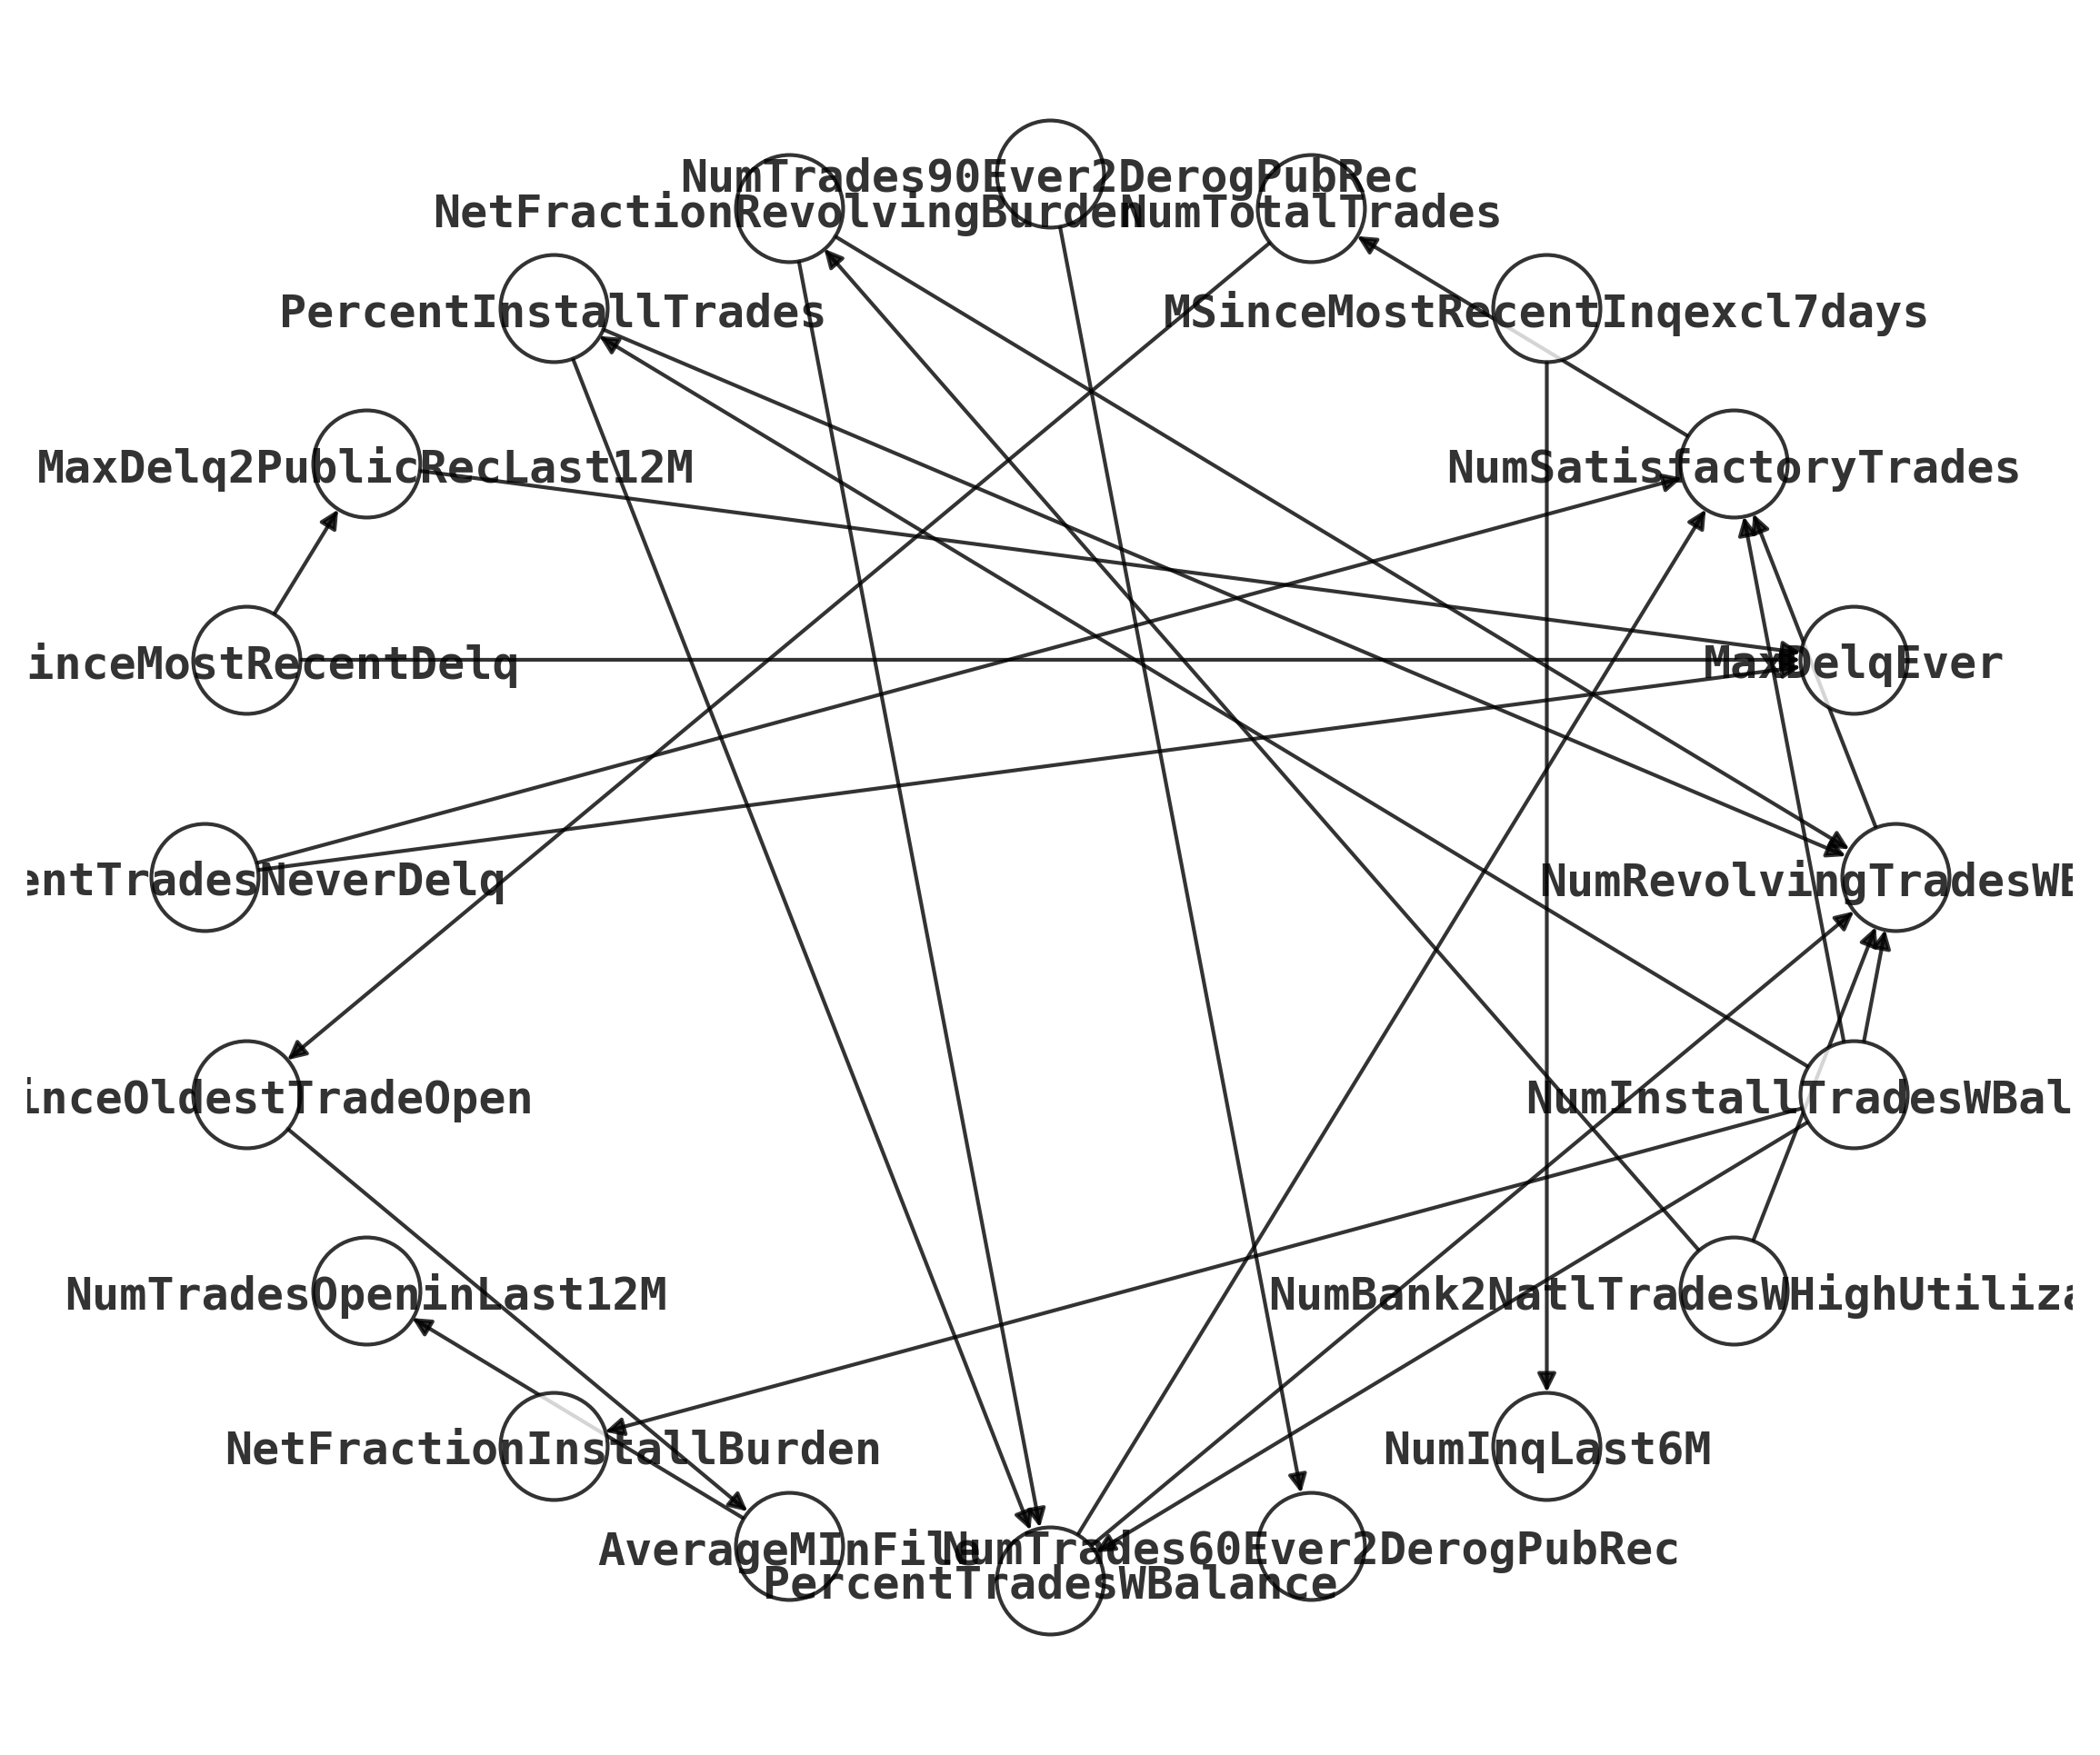

In [12]:
# Plot or inspect the learned graph
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [13]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_heloc/heloc_rex3_no_constraints.dot") 

### 2.2 With 4-tier prior constraints

In [14]:
prior = [
    # Tier 0 — Credit history length
    ["AverageMInFile", "MSinceOldestTradeOpen"],
    # Tier 1 — Portfolio size / structure
    [
        'NumTotalTrades',
        'NumSatisfactoryTrades',
        'PercentInstallTrades',
        'NumRevolvingTradesWBalance',
        'NumInstallTradesWBalance'
    ],
    # Tier 2 — Delinquency & recent activity
    [
        'NumTrades60Ever2DerogPubRec',
        'NumTrades90Ever2DerogPubRec',
        'PercentTradesNeverDelq',
        'MSinceMostRecentDelq',
        'MaxDelq2PublicRecLast12M',
        'MaxDelqEver',
        'NumTradesOpeninLast12M',
        'MSinceMostRecentInqexcl7days',
        'NumInqLast6M'
    ],
    # Tier 3 — Utilization / burden (most downstream)
    [
        'NetFractionRevolvingBurden',
        'NetFractionInstallBurden',
        'NumBank2NatlTradesWHighUtilization',
        'PercentTradesWBalance'
    ]
]


In [15]:
# NOTE: run with constraints: prior

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)



Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

In [16]:
# Numbers of trainer from REX
print(gd.trainer)
print()

# SHAP sampling summary
print(gd._sampling_summary())

{'heloc_processed_downsampled_nn': <causalexplain.common.notebook.Experiment object at 0x34bce8260>, 'heloc_processed_downsampled_gbt': <causalexplain.common.notebook.Experiment object at 0x340c83bf0>, 'heloc_processed_downsampled_rex': <causalexplain.common.notebook.Experiment object at 0x34edc0140>}

SHAP adaptive sampling: multi_sample (K=5, samples=512)


In [17]:
import networkx as nx

print(gd.dag.number_of_nodes())
print(gd.dag.number_of_edges())

20
19


In [18]:
# Adjacency matrix
import pandas as pd

adj_df = pd.DataFrame(
    nx.to_numpy_array(gd.dag, nodelist=gd.data_columns),
    index=gd.data_columns,
    columns=gd.data_columns
)

adj_df

,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,MaxDelqEver,NumTotalTrades,NumTradesOpeninLast12M,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance,MSinceOldestTradeOpen,AverageMInFile
NumSatisfactoryTrades,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
NumTrades60Ever2DerogPubRec,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
NumTrades90Ever2DerogPubRec,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
PercentTradesNeverDelq,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
MSinceMostRecentDelq,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
MaxDelq2PublicRecLast12M,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
MaxDelqEver,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000
NumTotalTrades,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
NumTradesOpeninLast12M,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
PercentInstallTrades,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


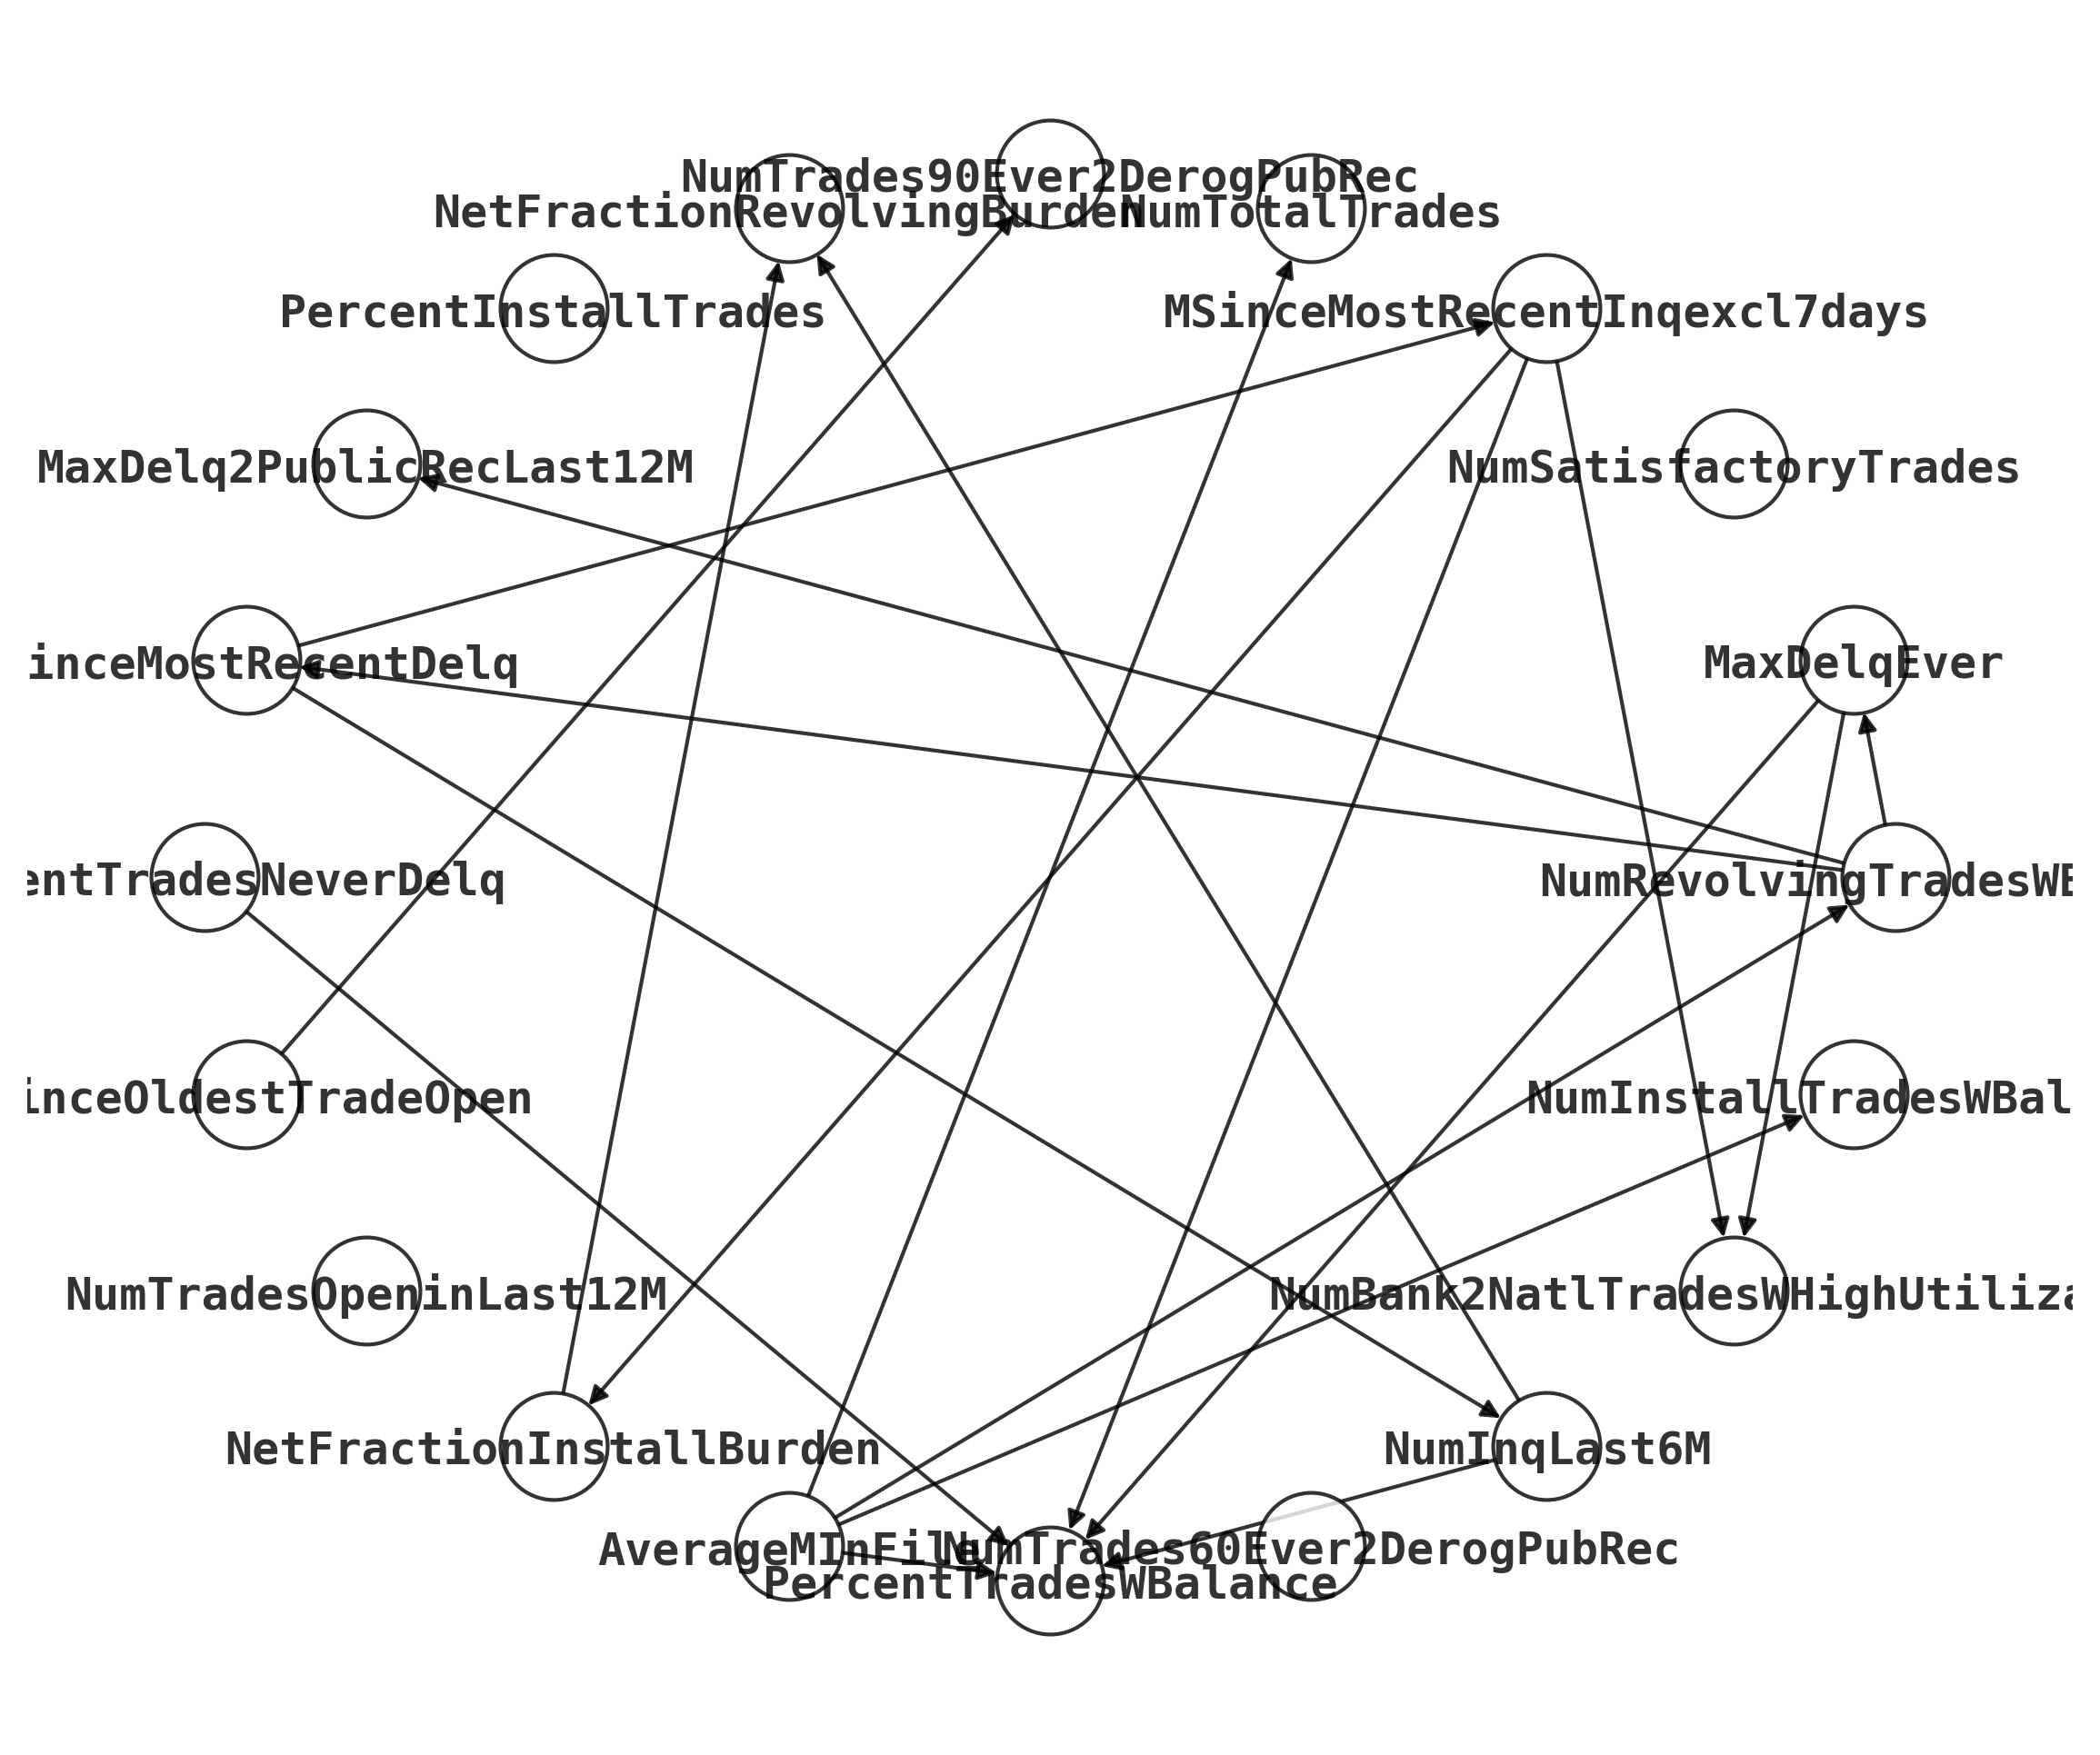

In [19]:
# Plot or inspect the learned graph
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [20]:
# gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [21]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_heloc/heloc_rex4_constraints.dot")

### 2.3 With minimal prior constraints

In [22]:
prior_minimal = [
    ["AverageMInFile", "MSinceOldestTradeOpen"],  # Credit history length, context variables
    [
        'NumSatisfactoryTrades',
        'NumTrades60Ever2DerogPubRec',
        'NumTrades90Ever2DerogPubRec',
        'PercentTradesNeverDelq',
        'MSinceMostRecentDelq',
        'MaxDelq2PublicRecLast12M',
        'MaxDelqEver',
        'NumTotalTrades',
        'NumTradesOpeninLast12M',
        'PercentInstallTrades',
        'MSinceMostRecentInqexcl7days',
        'NumInqLast6M',
        'NetFractionRevolvingBurden',
        'NetFractionInstallBurden',
        'NumRevolvingTradesWBalance',
        'NumInstallTradesWBalance',
        'NumBank2NatlTradesWHighUtilization',
        'PercentTradesWBalance'
    ]
]

In [23]:
# NOTE: run with constraints: prior_minimal

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior_minimal,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

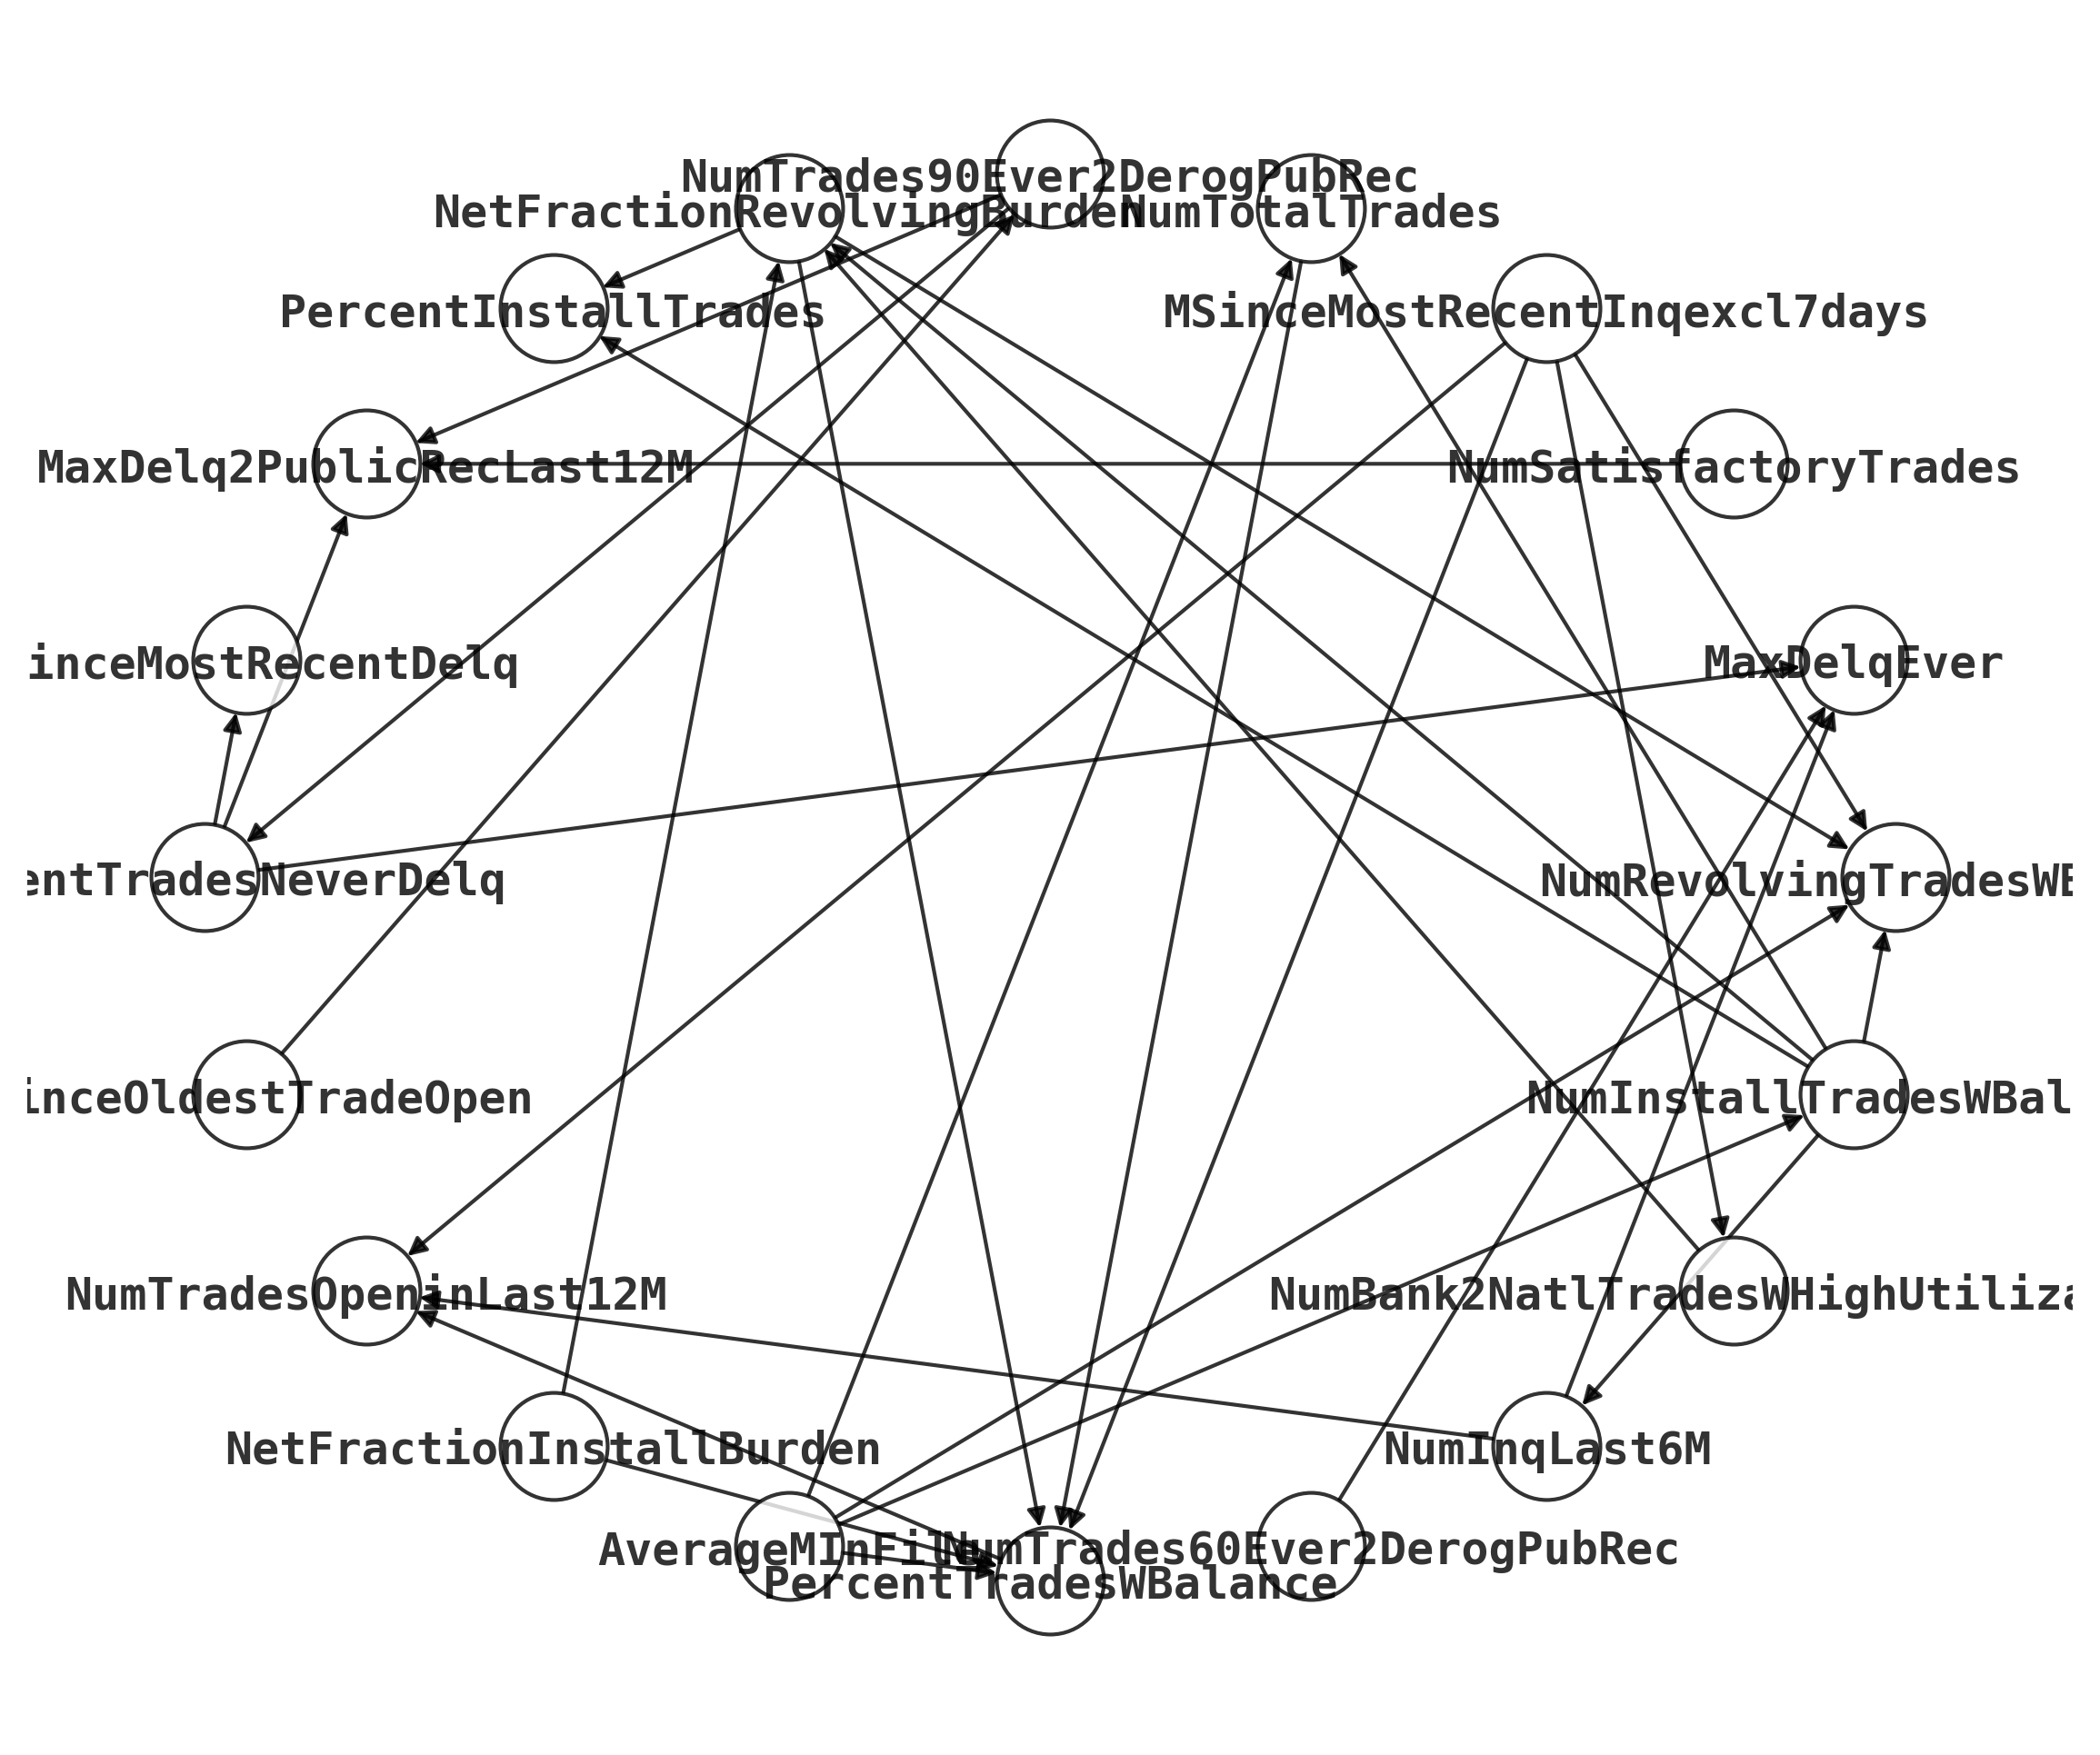

In [24]:
# Plot or inspect the learned graph
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [25]:
# gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [26]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_heloc/heloc_rex5_constraints_min.dot")

### 2.4 With moderate prior constraints

In [27]:
prior_mod = [
    # Tier 0 — Credit history length
    ["AverageMInFile", "MSinceOldestTradeOpen"],
    # Tier 1 — Portfolio size & structure
    [
        'NumTotalTrades',
        'NumSatisfactoryTrades',
        'PercentInstallTrades',
        'NumRevolvingTradesWBalance',
        'NumInstallTradesWBalance'
    ],
    # Tier 2 — Behavior, activity & financial stress
    [
        'NumTrades60Ever2DerogPubRec',
        'NumTrades90Ever2DerogPubRec',
        'PercentTradesNeverDelq',
        'MSinceMostRecentDelq',
        'MaxDelq2PublicRecLast12M',
        'MaxDelqEver',
        'NumTradesOpeninLast12M',
        'MSinceMostRecentInqexcl7days',
        'NumInqLast6M',
        'NetFractionRevolvingBurden',
        'NetFractionInstallBurden',
        'NumBank2NatlTradesWHighUtilization',
        'PercentTradesWBalance'
    ]
]

In [28]:
# NOTE: run with constraints: prior_minimal

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior_mod,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

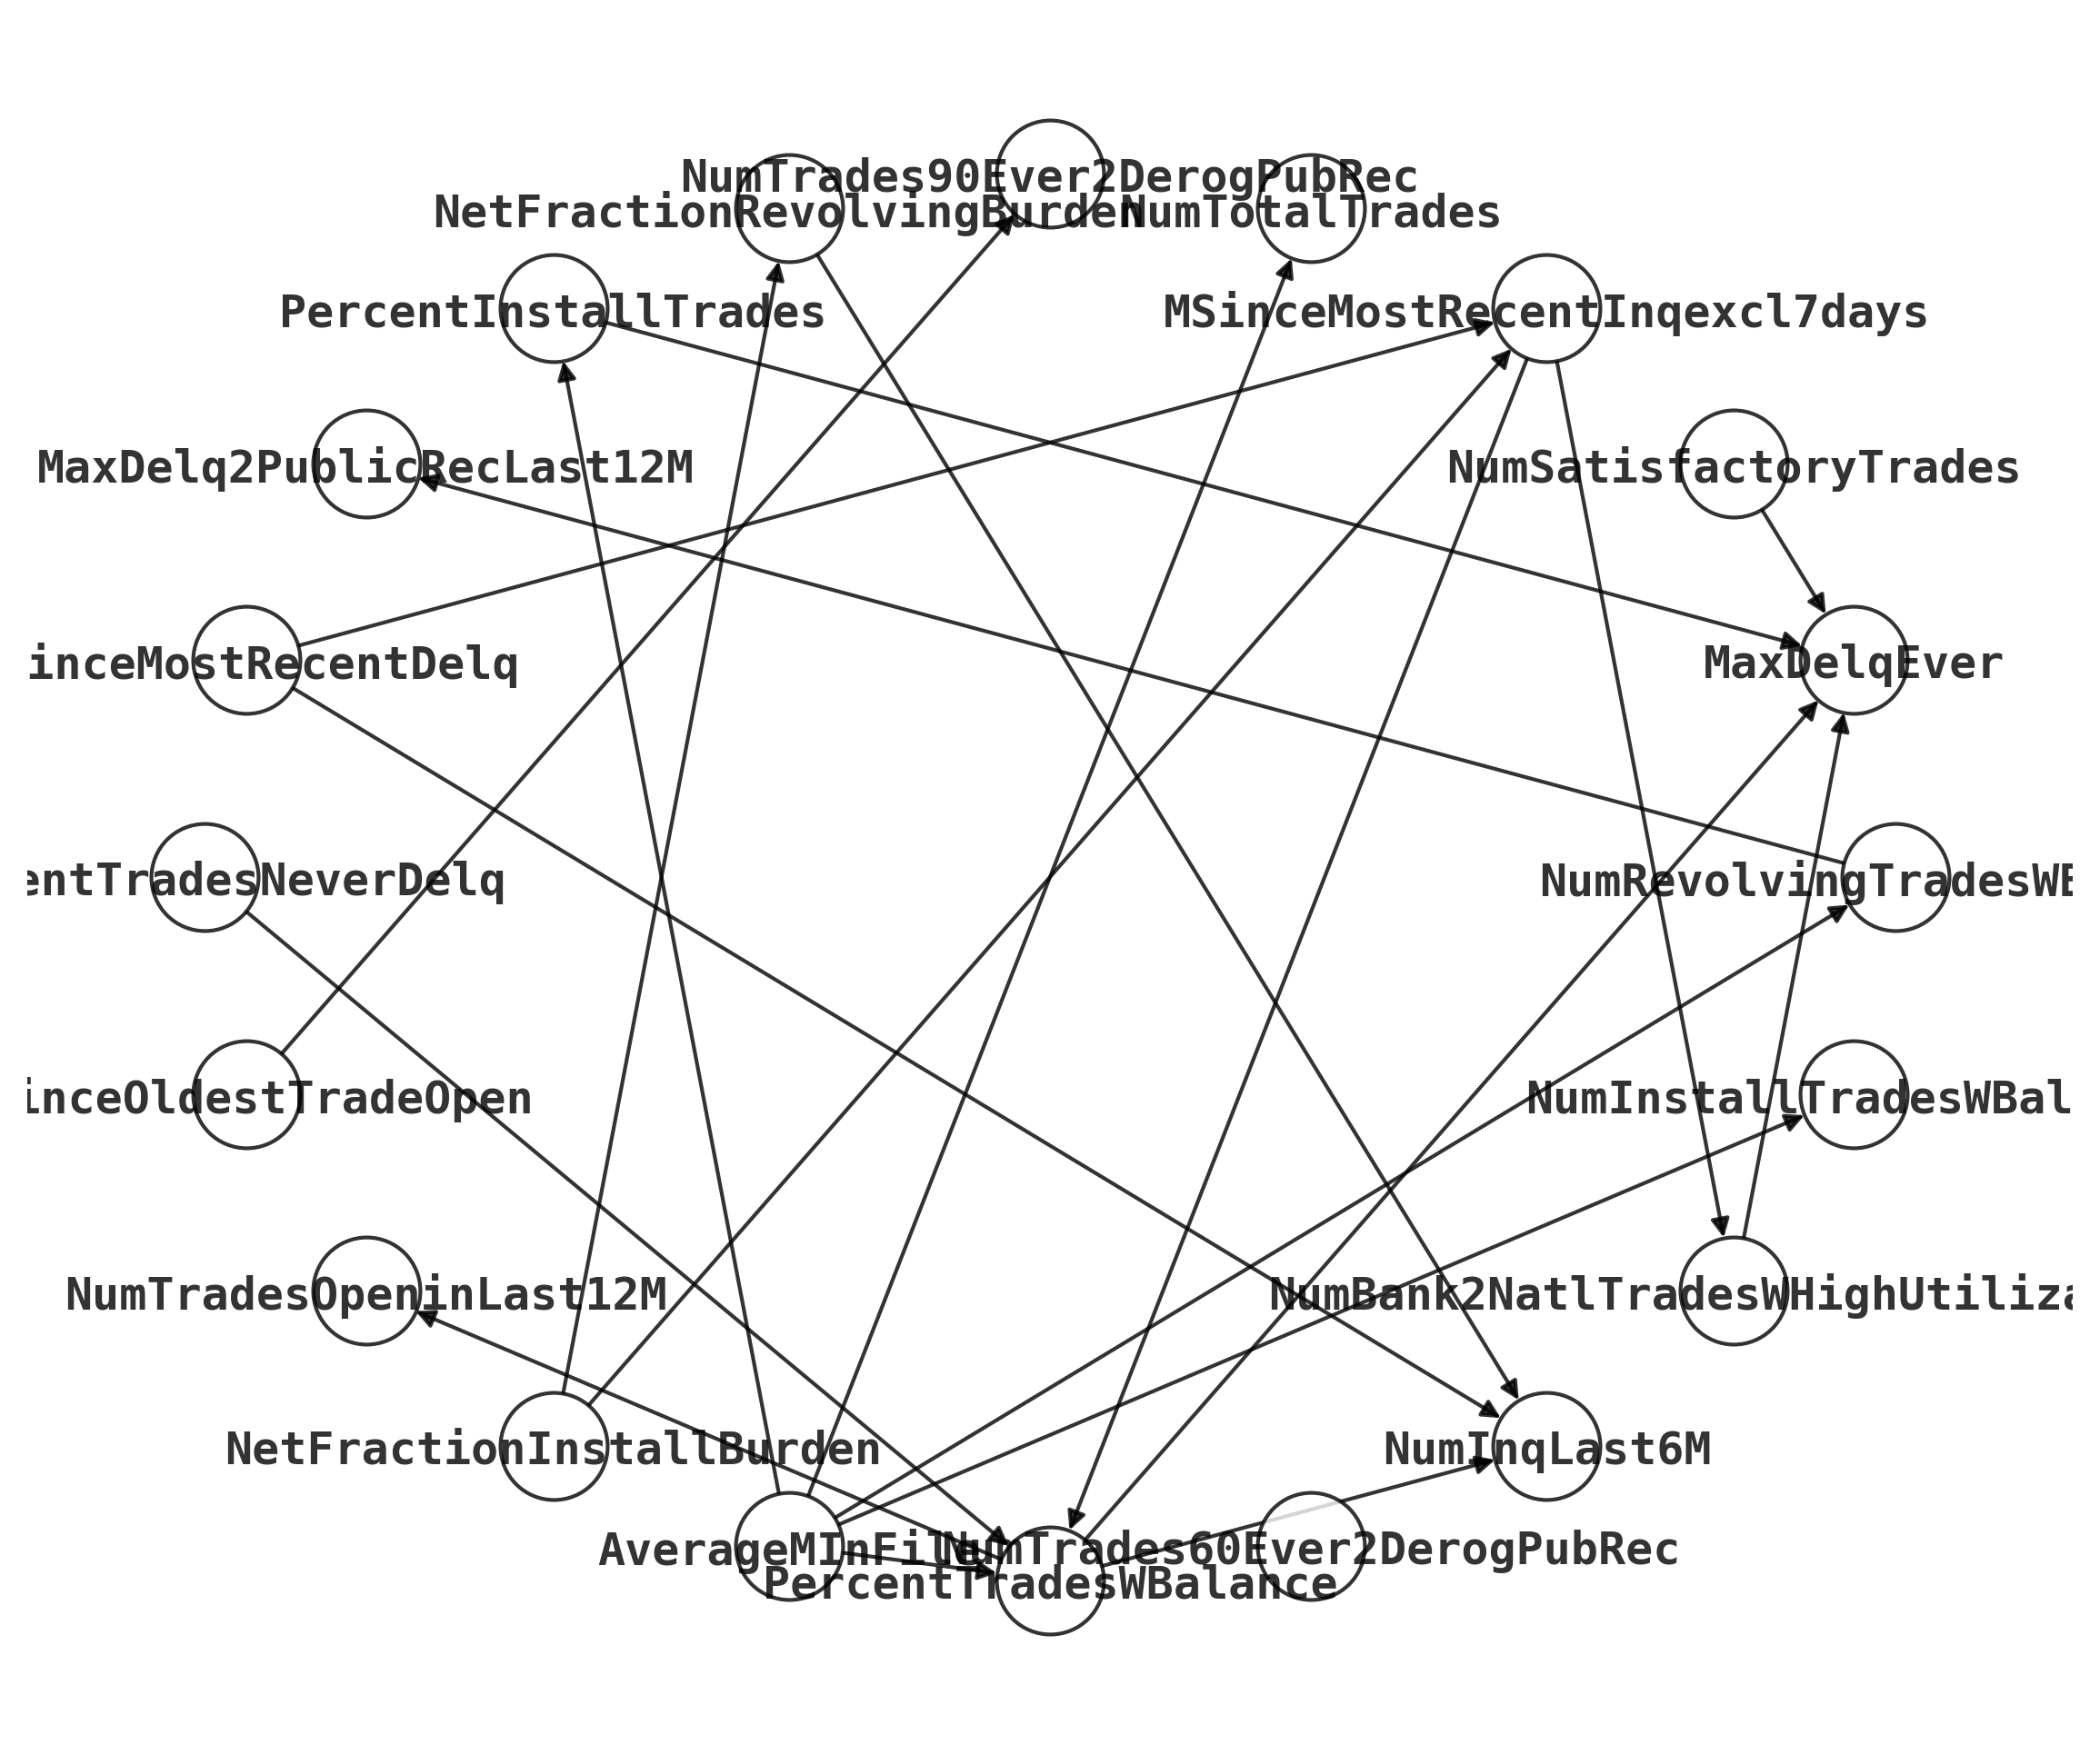

In [29]:
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [30]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_heloc/heloc_rex6_constraints_mod.dot")